In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve
)

In [2]:
train_data = pd.read_csv(
    "../data/processed/train_data.csv"
)

test_data = pd.read_csv(
    "../data/processed/test_data.csv"
)

X_train = train_data.drop(columns=["Fraud_Label"])
y_train = train_data["Fraud_Label"]

X_test = test_data.drop(columns=["Fraud_Label"])
y_test = test_data["Fraud_Label"]

In [3]:
preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

In [4]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [5]:
logistic_model = joblib.load(
    "../models/logistic_regression.pkl"
)

rf_model = joblib.load(
    "../models/random_forest.pkl"
)

xgb_model = joblib.load(
    "../models/xgboost_model.pkl"
)

In [6]:
logistic_pred = logistic_model.predict(
    X_test_processed
)

logistic_proba = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [7]:
rf_pred = rf_model.predict(
    X_test_processed
)

rf_proba = rf_model.predict_proba(
    X_test_processed
)[:, 1]

In [8]:
rf_pred = rf_model.predict(
    X_test_processed
)

rf_proba = rf_model.predict_proba(
    X_test_processed
)[:, 1]

In [9]:
xgb_pred = xgb_model.predict(
    X_test_processed
)

xgb_proba = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [10]:
def evaluate_model(
    name,
    y_true,
    predictions,
    probabilities
):
    return {
        "Model": name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1_Score": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            probabilities
        ),
        "PR_AUC": average_precision_score(
            y_true,
            probabilities
        )
    }

In [11]:
results = [
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_proba
    ),
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_proba
    ),
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred,
        xgb_proba
    )
]

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
0,Logistic Regression,0.6787,0.000000,0.000000,0.000000,0.491198,0.318017
1,Random Forest,0.6786,0.400000,0.000622,0.001243,0.503003,0.326929
2,XGBoost,0.6719,0.295181,0.015251,0.029003,0.496757,0.320843


In [12]:
cm_lr = confusion_matrix(
    y_test,
    logistic_pred
)

print(cm_lr)

[[6787    0]
 [3213    0]]


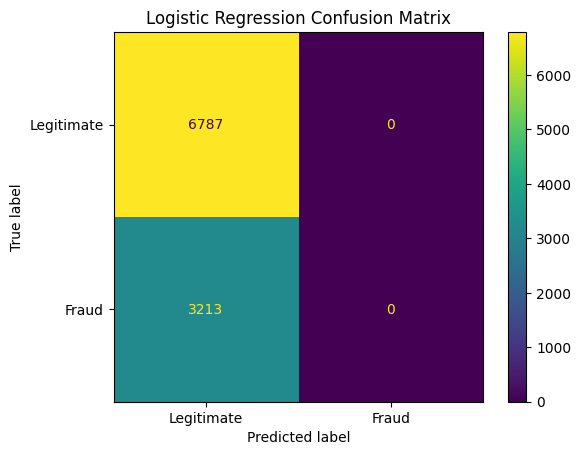

In [13]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

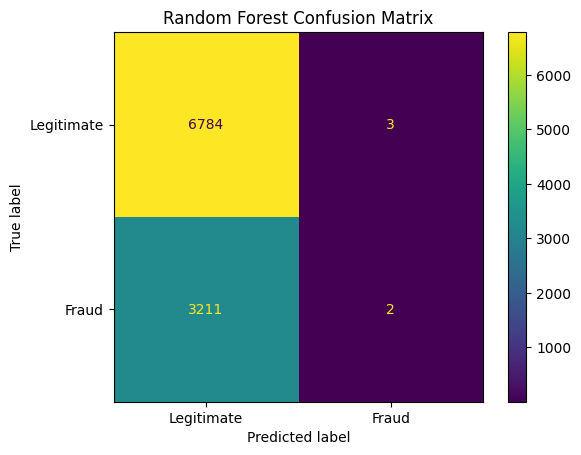

In [14]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

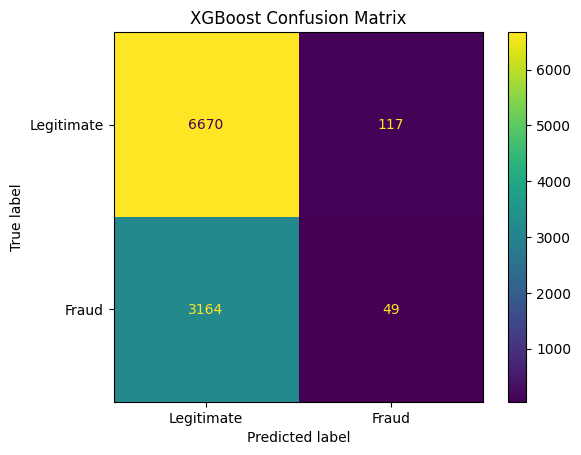

In [15]:
cm_xgb = confusion_matrix(
    y_test,
    xgb_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

In [16]:
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=[
            "Legitimate",
            "Fraud"
        ]
    )
)

              precision    recall  f1-score   support

  Legitimate       0.68      0.98      0.80      6787
       Fraud       0.30      0.02      0.03      3213

    accuracy                           0.67     10000
   macro avg       0.49      0.50      0.42     10000
weighted avg       0.56      0.67      0.55     10000



In [17]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=[
            "Legitimate",
            "Fraud"
        ]
    )
)

              precision    recall  f1-score   support

  Legitimate       0.68      1.00      0.81      6787
       Fraud       0.40      0.00      0.00      3213

    accuracy                           0.68     10000
   macro avg       0.54      0.50      0.40     10000
weighted avg       0.59      0.68      0.55     10000



In [18]:
print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=[
            "Legitimate",
            "Fraud"
        ]
    )
)

              precision    recall  f1-score   support

  Legitimate       0.68      1.00      0.81      6787
       Fraud       0.00      0.00      0.00      3213

    accuracy                           0.68     10000
   macro avg       0.34      0.50      0.40     10000
weighted avg       0.46      0.68      0.55     10000



C:\Users\anilk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\anilk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\anilk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1469

In [19]:
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    logistic_proba
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_proba
)

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_proba
)

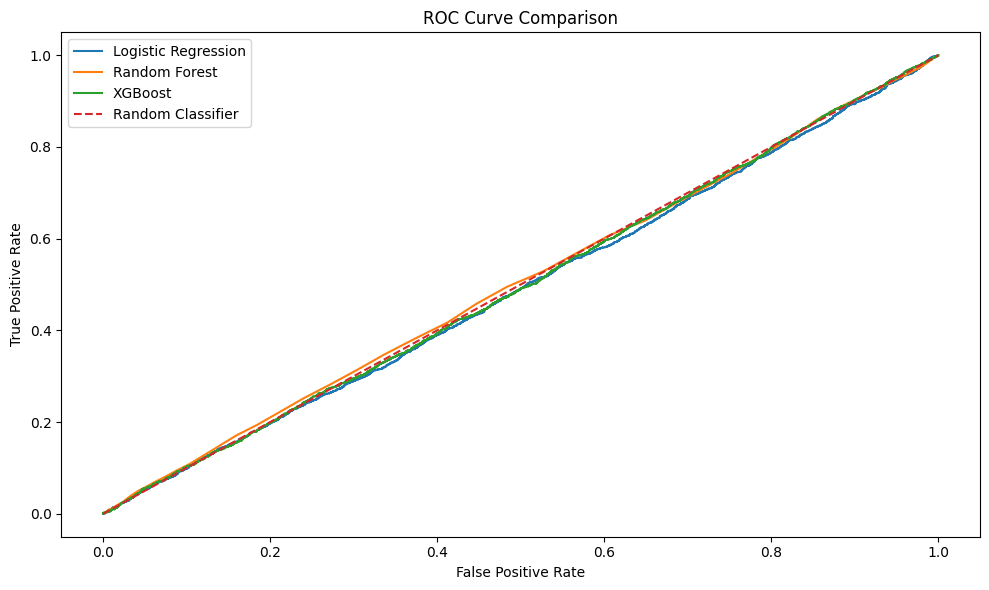

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.show()

In [21]:
lr_precision, lr_recall, _ = precision_recall_curve(
    y_test,
    logistic_proba
)

rf_precision, rf_recall, _ = precision_recall_curve(
    y_test,
    rf_proba
)

xgb_precision, xgb_recall, _ = precision_recall_curve(
    y_test,
    xgb_proba
)

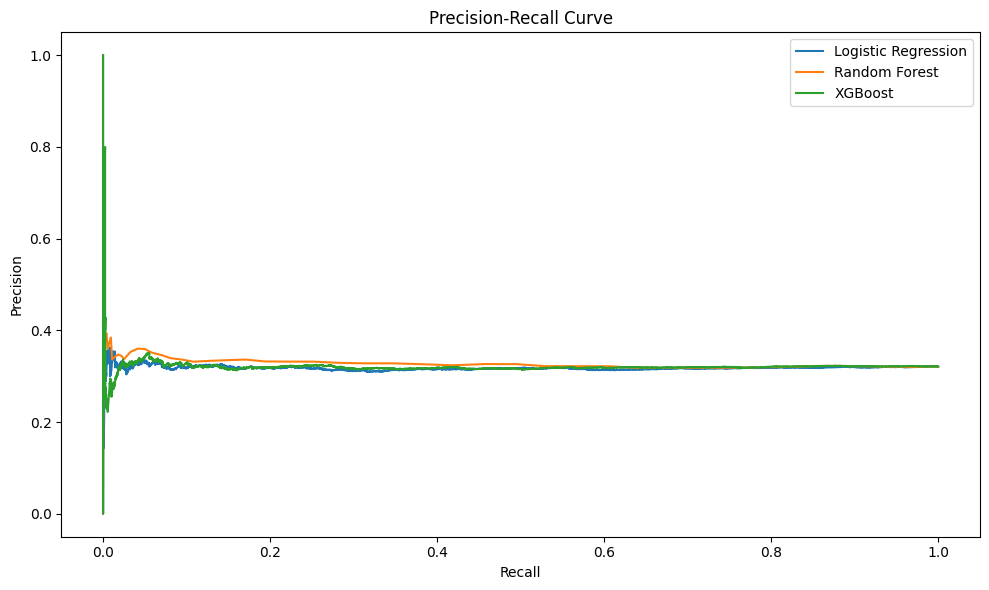

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    lr_recall,
    lr_precision,
    label="Logistic Regression"
)

plt.plot(
    rf_recall,
    rf_precision,
    label="Random Forest"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.tight_layout()

plt.show()

In [23]:
results_df.sort_values(
    by="F1_Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
2,XGBoost,0.6719,0.295181,0.015251,0.029003,0.496757,0.320843
1,Random Forest,0.6786,0.400000,0.000622,0.001243,0.503003,0.326929
0,Logistic Regression,0.6787,0.000000,0.000000,0.000000,0.491198,0.318017


In [24]:
results_df.sort_values(
    by="PR_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
1,Random Forest,0.6786,0.400000,0.000622,0.001243,0.503003,0.326929
2,XGBoost,0.6719,0.295181,0.015251,0.029003,0.496757,0.320843
0,Logistic Regression,0.6787,0.000000,0.000000,0.000000,0.491198,0.318017


In [25]:
results_df.sort_values(
    by="Recall",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
2,XGBoost,0.6719,0.295181,0.015251,0.029003,0.496757,0.320843
1,Random Forest,0.6786,0.400000,0.000622,0.001243,0.503003,0.326929
0,Logistic Regression,0.6787,0.000000,0.000000,0.000000,0.491198,0.318017


In [26]:
best_model_name = results_df.loc[
    results_df["F1_Score"].idxmax(),
    "Model"
]

print(
    "Best model:",
    best_model_name
)

Best model: XGBoost


In [27]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

In [28]:
final_model = models[best_model_name]

In [29]:
joblib.dump(
    final_model,
    "../models/fraud_model.pkl"
)

['../models/fraud_model.pkl']

In [30]:
with open(
    "../models/final_model_name.txt",
    "w"
) as f:
    f.write(best_model_name)

In [31]:
if best_model_name == "XGBoost":

    importance = final_model.feature_importances_

    print(
        "Number of feature importance values:",
        len(importance)
    )

Number of feature importance values: 33


In [32]:
feature_names = preprocessor.get_feature_names_out()

In [33]:
print(
    len(feature_names)
)

print(
    feature_names[:20]
)

33
['num__Transaction_Amount' 'num__Account_Balance'
 'num__Previous_Fraudulent_Activity' 'num__Daily_Transaction_Count'
 'num__Card_Age' 'num__Txn_to_Balance_Pct' 'num__Amount_Zscore_User'
 'num__Year' 'num__Month' 'num__Day' 'num__Day_of_Week' 'num__Is_Weekend'
 'cat__Transaction_Type_ATM Withdrawal'
 'cat__Transaction_Type_Bank Transfer' 'cat__Transaction_Type_Online'
 'cat__Transaction_Type_POS' 'cat__Device_Type_Laptop'
 'cat__Device_Type_Mobile' 'cat__Device_Type_Tablet'
 'cat__Location_London']


In [34]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_model.feature_importances_
})

In [35]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [36]:
importance_df.head(20)

,Feature,Importance
23,cat__Location_Tokyo,0.035371
5,num__Txn_to_Balance_Pct,0.033908
27,cat__Merchant_Category_Restaurants,0.033457
0,num__Transaction_Amount,0.033447
1,num__Account_Balance,0.033254
6,num__Amount_Zscore_User,0.033225
4,num__Card_Age,0.033191
2,num__Previous_Fraudulent_Activity,0.033026
21,cat__Location_New York,0.032952
28,cat__Merchant_Category_Travel,0.032486


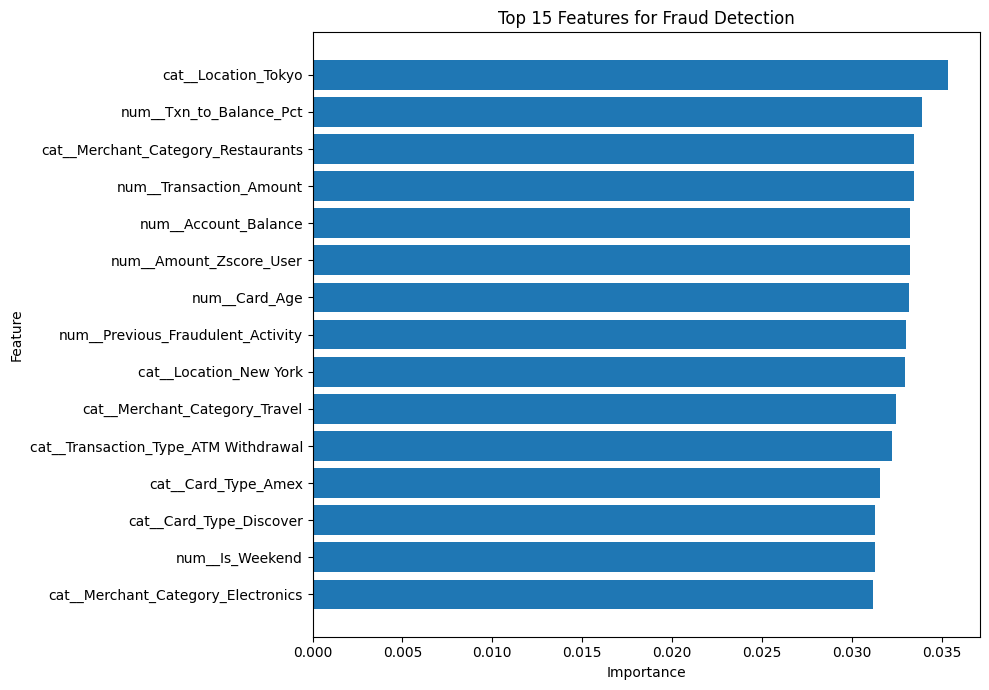

In [37]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Features for Fraud Detection"
)

plt.tight_layout()

plt.show()

In [38]:
importance_df.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

In [39]:
results_df.to_csv(
    "../reports/final_model_evaluation.csv",
    index=False
)

In [40]:
final_results = results_df[
    results_df["Model"] == best_model_name
]

print("====================================")
print(" FINAL FRAUD DETECTION MODEL")
print("====================================")

print(
    "Model:",
    best_model_name
)

print(
    "Accuracy:",
    round(
        final_results["Accuracy"].iloc[0],
        4
    )
)

print(
    "Precision:",
    round(
        final_results["Precision"].iloc[0],
        4
    )
)

print(
    "Recall:",
    round(
        final_results["Recall"].iloc[0],
        4
    )
)

print(
    "F1 Score:",
    round(
        final_results["F1_Score"].iloc[0],
        4
    )
)

print(
    "ROC-AUC:",
    round(
        final_results["ROC_AUC"].iloc[0],
        4
    )
)

print(
    "PR-AUC:",
    round(
        final_results["PR_AUC"].iloc[0],
        4
    )
)

 FINAL FRAUD DETECTION MODEL
Model: XGBoost
Accuracy: 0.6719
Precision: 0.2952
Recall: 0.0153
F1 Score: 0.029
ROC-AUC: 0.4968
PR-AUC: 0.3208


In [41]:
results_df

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
0,Logistic Regression,0.6787,0.000000,0.000000,0.000000,0.491198,0.318017
1,Random Forest,0.6786,0.400000,0.000622,0.001243,0.503003,0.326929
2,XGBoost,0.6719,0.295181,0.015251,0.029003,0.496757,0.320843
